<img src="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/imgs/banner_fcd.jpg?raw=1" alt="bannersp" width="1100"  height="150">

# <span style="color:#2F749F;"><strong>📦 Sesión práctica 3: Codificación y transformación de variables</strong></span>
---
<p align="right">
  <a href="https://colab.research.google.com/github/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_3_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>

## <span style="color:black;"><strong>Datos del estudiante</strong></span>

* Natalia Bernal Gutierrez
* Julián Camilo Carvajal Mellizo

In [ ]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine, load_diabetes, fetch_california_housing
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from scipy.stats import zscore

## <span style="color:#2F749F;"><strong>Ejercicio 1: Comparación de métodos de escalamiento</strong></span>

A partir de un conjunto de datos real sobre **vinos**, analiza cómo cambia la escala de las variables al aplicar diferentes métodos de **escalamiento de datos**, y compara visualmente sus efectos sobre la distribución.

1. Carga el conjunto de datos **wine** desde la librería `sklearn.datasets` usando `load_wine()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `alcohol`
   - `malic_acid`
   - `color_intensity`

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - `StandardScaler`
   - `MinMaxScaler`
   - `RobustScaler`
   - `Z-Score`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **StandardScaler**
   - Distribución con **MinMaxScaler**
   - Distribución con **RobustScaler**
   - Distribución con **Z-Score**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [ ]:
# Cargar el conjunto de datos
wine = load_wine()

# Convertir en dataframe
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Visualizar la forma y las primeras filas
print(df.shape)
df.head()

(178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
# Selección de variables
variables = ['alcohol', 'malic_acid', 'color_intensity']

df_selected = df[variables].copy()

# Escalamiento

# Inicializar scalers
minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

# Crear DataFrame para guardar resultados
df_scaled = pd.DataFrame()

for col in variables:
    # Mantener original
    df_scaled[f'{col}_original'] = df_selected[col]

    # MinMax
    df_scaled[f'{col}_minmax'] = minmax_scaler.fit_transform(df_selected[[col]])

    # StandardScaler
    df_scaled[f'{col}_standard'] = standard_scaler.fit_transform(df_selected[[col]])

    # Z-score
    df_scaled[f'{col}_zscore'] = zscore(df_selected[col])

    # RobustScaler
    df_scaled[f'{col}_robust'] = robust_scaler.fit_transform(df_selected[[col]])

# Ver primeras filas
df_scaled.head()

,alcohol_original,alcohol_minmax,alcohol_standard,alcohol_zscore,alcohol_robust,malic_acid_original,malic_acid_minmax,malic_acid_standard,malic_acid_zscore,malic_acid_robust,color_intensity_original,color_intensity_minmax,color_intensity_standard,color_intensity_zscore,color_intensity_robust
0,14.23,0.842105,1.518613,1.518613,0.897338,1.71,0.191700,-0.562250,-0.562250,-0.104730,5.64,0.372014,0.251717,0.251717,0.318792
1,13.20,0.571053,0.246290,0.246290,0.114068,1.78,0.205534,-0.499413,-0.499413,-0.057432,4.38,0.264505,-0.293321,-0.293321,-0.104027
2,13.16,0.560526,0.196879,0.196879,0.083650,2.36,0.320158,0.021231,0.021231,0.334459,5.68,0.375427,0.269020,0.269020,0.332215
3,14.37,0.878947,1.691550,1.691550,1.003802,1.95,0.239130,-0.346811,-0.346811,0.057432,7.80,0.556314,1.186068,1.186068,1.043624
4,13.24,0.581579,0.295700,0.295700,0.144487,2.59,0.365613,0.227694,0.227694,0.489865,4.32,0.259386,-0.319276,-0.319276,-0.124161


Graficas comparativas

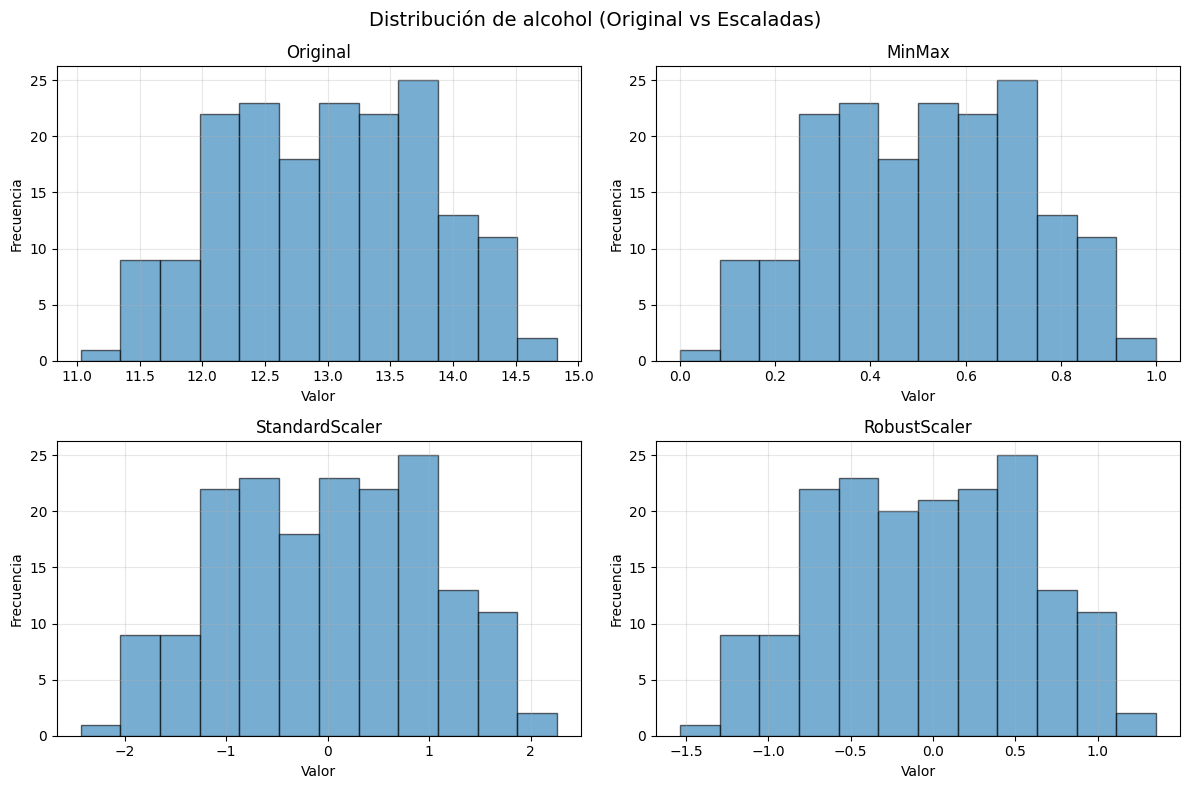

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribución de alcohol (Original vs Escaladas)', fontsize=14)

transformaciones = [
    ('alcohol_original', 'Original'),
    ('alcohol_minmax', 'MinMax'),
    ('alcohol_standard', 'StandardScaler'),
    ('alcohol_robust', 'RobustScaler') # z-scaler es lo mismo, no graficamos
]

axs = axs.flatten()

for i, (col, titulo) in enumerate(transformaciones):
    # Histograma
    axs[i].hist(
        df_scaled[col],
        bins=12,
        alpha=0.6,
        edgecolor='black'
    )

    axs[i].set_title(titulo)
    axs[i].set_xlabel('Valor')
    axs[i].set_ylabel('Frecuencia')
    axs[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

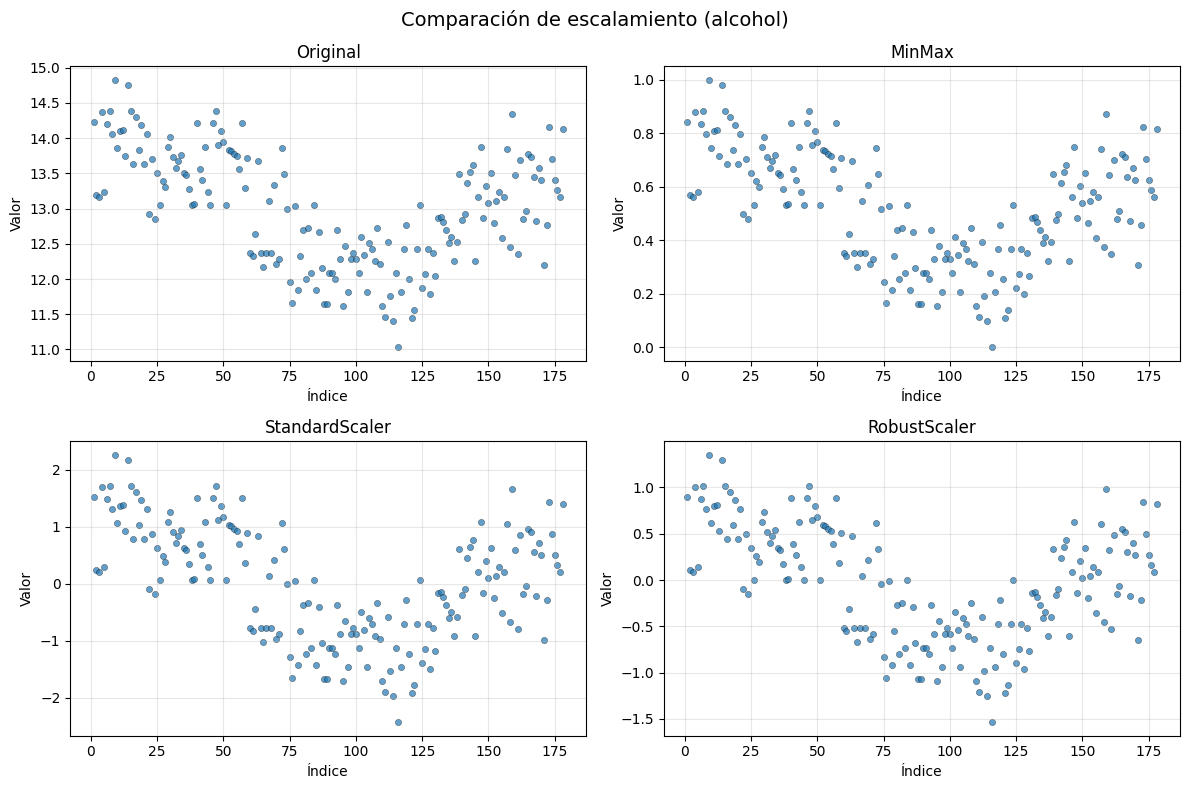

In [ ]:
indices = np.arange(1, len(df_scaled) + 1)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Comparación de escalamiento (alcohol)', fontsize=14)

axs = axs.flatten()

for i, (col, titulo) in enumerate(transformaciones):
    axs[i].scatter(
        indices,
        df_scaled[col],
        alpha=0.7,
        s=20,
        edgecolors='black',
        linewidth=0.3
    )

    axs[i].set_title(titulo)
    axs[i].set_xlabel('Índice')
    axs[i].set_ylabel('Valor')
    axs[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis

Las transformaciones aplicadas **no alteran la forma de la distribución**, sino únicamente la escala de los datos, como se observa tanto en los histogramas como en los scatter plots. MinMaxScaler reescala los valores al rango [0,1], mientras que StandardScaler los centra en torno a cero con base en la desviación estándar. RobustScaler por su parte, muestra un comportamiento similar aunque es más robusto ante datos atípicos. Dado que no se evidencian outliers en las gráficas, **StandardScaler** podría ser una opción adecuada para estandarizar los datos de esta variable. Aunque si planea utilizar un algoritmo que requiera un rango fijo, **minMax** también resulta una excelente opción.

## <span style="color:#2F749F;"><strong>Ejercicio 2: Comparación de escalamiento RobustScaler vs Z-Score</strong></span>

A partir de un conjunto de datos real sobre **diabetes**, analiza cómo cambia la escala de las variables al aplicar **estandarización con Z-Score** y **escalamiento robusto**, y compara visualmente sus efectos cuando existen **posibles valores atípicos**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo: `bmi`, `bp`, `s5` u otras disponibles en el dataset).

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - **StandardScaler** (Z-Score).
   - **RobustScaler** (basado en mediana e IQR).

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución **escalada con Z-Score**
   - Distribución **escalada con RobustScaler**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [ ]:
# Cargar el conjunto de datos
diabetes = load_diabetes()

# Convertir en dataframe
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Visualizar la forma y las primeras filas
print(df.shape)
df.head()

(442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [ ]:
# Selección de variables
variables = ['bmi', 'bp', 's5']

df_selected = df[variables].copy()

# Escalamiento

# Inicializar scalers
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

# Crear DataFrame para guardar resultados
df_scaled = pd.DataFrame()

for col in variables:
    # Mantener original
    df_scaled[f'{col}_original'] = df_selected[col]

    # StandardScaler
    df_scaled[f'{col}_standard'] = standard_scaler.fit_transform(df_selected[[col]])

    # RobustScaler
    df_scaled[f'{col}_robust'] = robust_scaler.fit_transform(df_selected[[col]])

# Ver primeras filas
df_scaled.head()

,bmi_original,bmi_standard,bmi_robust,bp_original,bp_standard,bp_robust,s5_original,s5_standard,s5_robust
0,0.061696,1.297088,1.053498,0.021872,0.459841,0.380952,0.019907,0.418531,0.332755
1,-0.051474,-1.082180,-0.674897,-0.026328,-0.553505,-0.285714,-0.068332,-1.436589,-1.010756
2,0.044451,0.934533,0.790123,-0.005670,-0.119214,0.000000,0.002861,0.060156,0.073213
3,-0.011595,-0.243771,-0.065844,-0.036656,-0.770650,-0.428571,0.022688,0.476983,0.375087
4,-0.036385,-0.764944,-0.444444,0.021872,0.459841,0.380952,-0.031988,-0.672502,-0.457391


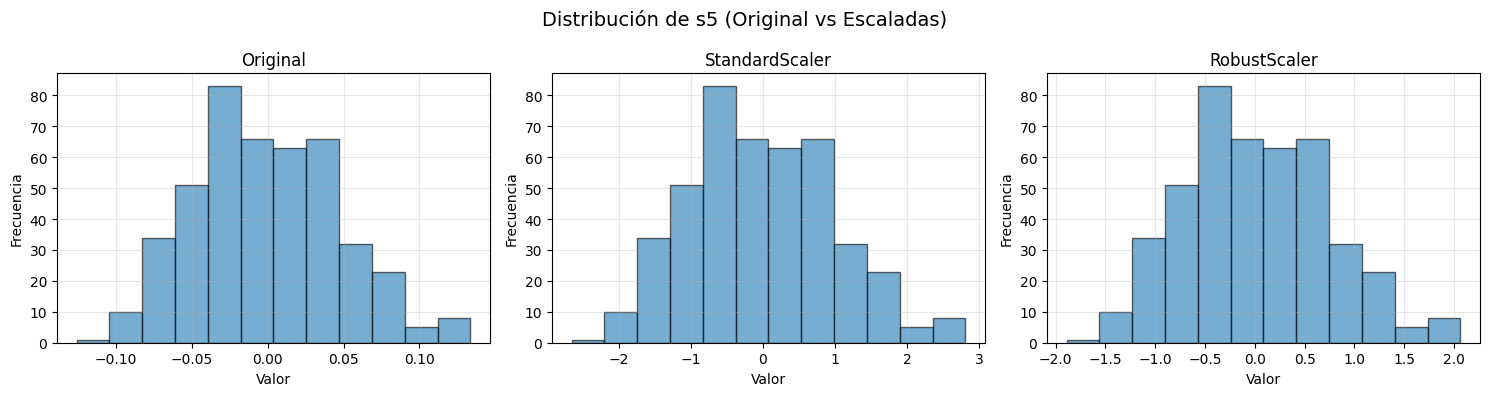

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribución de s5 (Original vs Escaladas)', fontsize=14)

transformaciones = [
    ('s5_original', 'Original'),
    ('s5_standard', 'StandardScaler'),
    ('s5_robust', 'RobustScaler')
]

for i, (col, titulo) in enumerate(transformaciones):
    # Histograma
    axs[i].hist(
        df_scaled[col],
        bins=12,
        alpha=0.6,
        edgecolor='black'
    )

    axs[i].set_title(titulo)
    axs[i].set_xlabel('Valor')
    axs[i].set_ylabel('Frecuencia')
    axs[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

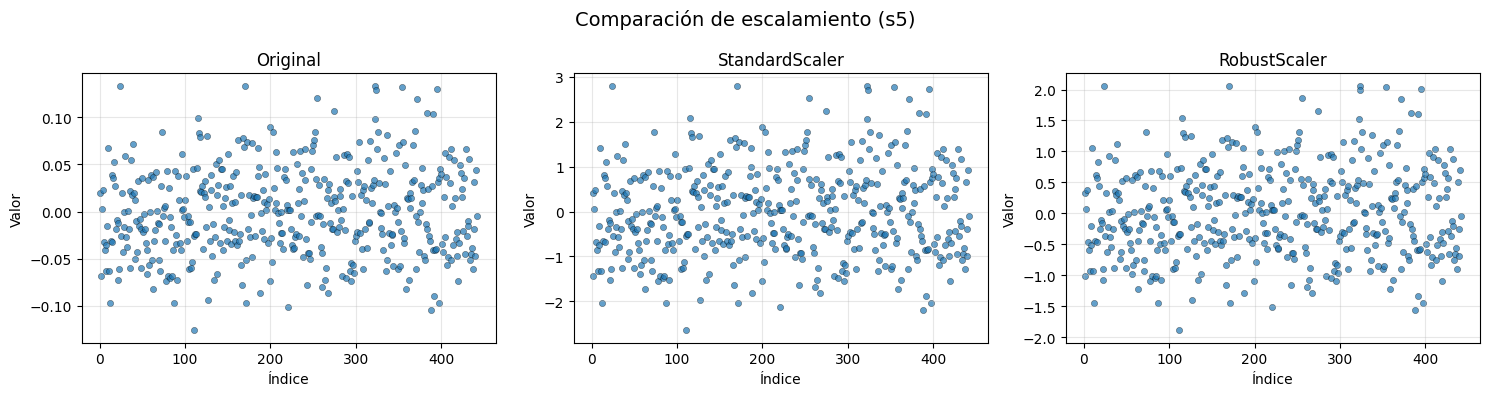

In [ ]:
indices = np.arange(1, len(df_scaled) + 1)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Comparación de escalamiento (s5)', fontsize=14)

axs = axs.flatten()

for i, (col, titulo) in enumerate(transformaciones):
    axs[i].scatter(
        indices,
        df_scaled[col],
        alpha=0.7,
        s=20,
        edgecolors='black',
        linewidth=0.3
    )

    axs[i].set_title(titulo)
    axs[i].set_xlabel('Índice')
    axs[i].set_ylabel('Valor')
    axs[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis

Las transformaciones no cambian la forma de la distribución, solo su escala. En las gráficas no se observan valores atípicos importantes, por lo que StandardScaler y RobustScaler generan resultados muy similares. La diferencia principal es que uno usa media y desviación estándar, mientras el otro usa mediana e IQR. En este caso, StandardScaler es suficiente al no haber outliers relevantes.

## <span style="color:#2F749F;"><strong>Ejercicio 3: Comparación de normalización L1 y L2</strong></span>

A partir de un conjunto de datos real sobre **precios de viviendas**, analiza cómo cambian los valores de las variables al aplicar **normalización L1 y L2**, y compara visualmente sus efectos sobre la distribución de los datos.

1. Carga el conjunto de datos **California Housing** desde la librería `sklearn.datasets` usando `fetch_california_housing()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `MedInc`
   - `AveRooms`
   - `HouseAge`

4. Aplica los siguientes métodos de **normalización** sobre las variables seleccionadas utilizando `Normalizer` de `sklearn.preprocessing`:
   - **Normalización L1**
   - **Normalización L2**

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **normalización L1**
   - Distribución con **normalización L2**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [ ]:
# Cargar conjunto de datos
california = fetch_california_housing()

# Convertir a DF
df = pd.DataFrame(california.data, columns=california.feature_names)

# Visualizar la forma y las primeras filas
print(df.shape)
df.head()

(20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
from sklearn.preprocessing import Normalizer

# Seleccionar variables
variables = ['MedInc', 'HouseAge', 'AveRooms']
X = df[variables].copy()

display(X.head())
print()

# L1
norm_l1 = Normalizer(norm='l1')
X_l1 = norm_l1.fit_transform(X)

# L2
norm_l2 = Normalizer(norm='l2')
X_l2 = norm_l2.fit_transform(X)

# Convertir a DataFrame
df_l1 = pd.DataFrame(X_l1, columns=variables)
df_l2 = pd.DataFrame(X_l2, columns=variables)

display(df_l1.head())
print()
display(df_l2.head())

,MedInc,HouseAge,AveRooms
0,8.3252,41.0,6.984127
1,8.3014,21.0,6.238137
2,7.2574,52.0,8.288136
3,5.6431,52.0,5.817352
4,3.8462,52.0,6.281853


,MedInc,HouseAge,AveRooms
0,0.147848,0.728121,0.124031
1,0.233582,0.590891,0.175527
2,0.107445,0.769851,0.122704
3,0.088923,0.819408,0.091669
4,0.061908,0.836981,0.101111


,MedInc,HouseAge,AveRooms
0,0.196277,0.966624,0.164659
1,0.354351,0.896399,0.266279
2,0.136535,0.978287,0.155926
3,0.107227,0.988071,0.110538
4,0.073234,0.990116,0.119611


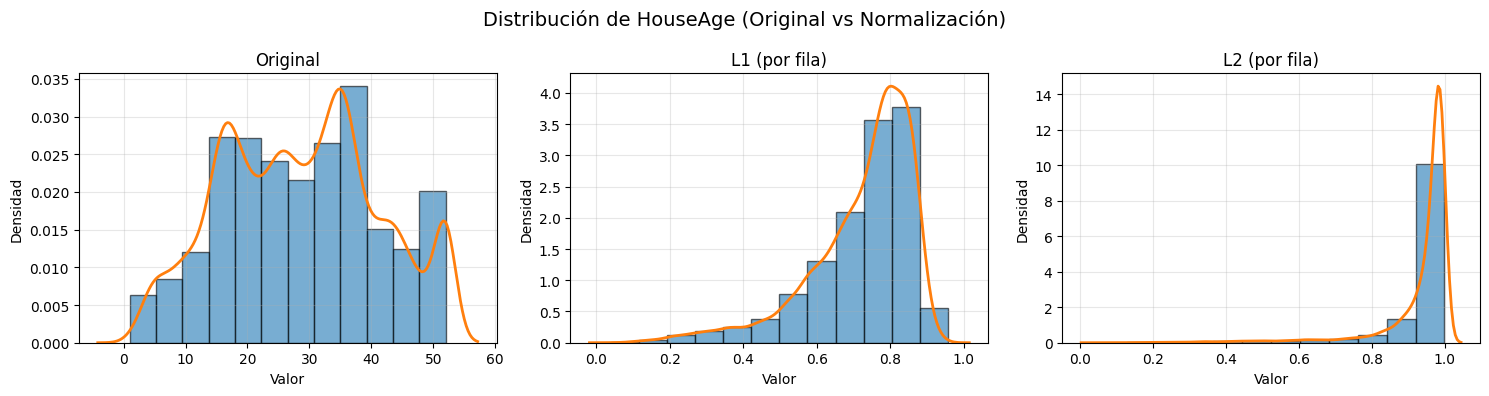

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribución de HouseAge (Original vs Normalización)', fontsize=14)

# Original
axs[0].hist(
    X['HouseAge'],
    bins=12,
    density=True,
    alpha=0.6,
    edgecolor='black'
)

sns.kdeplot(X['HouseAge'], ax=axs[0], linewidth=2)

axs[0].set_title('Original')
axs[0].set_xlabel('Valor')
axs[0].set_ylabel('Densidad')
axs[0].grid(True, alpha=0.3)


# L1
axs[1].hist(
    df_l1['HouseAge'],
    bins=12,
    density=True,
    alpha=0.6,
    edgecolor='black'
)

sns.kdeplot(df_l1['HouseAge'], ax=axs[1], linewidth=2)

axs[1].set_title('L1 (por fila)')
axs[1].set_xlabel('Valor')
axs[1].set_ylabel('Densidad')
axs[1].grid(True, alpha=0.3)


# L2
axs[2].hist(
    df_l2['HouseAge'],
    bins=12,
    density=True,
    alpha=0.6,
    edgecolor='black'
)

sns.kdeplot(df_l2['HouseAge'], ax=axs[2], linewidth=2)

axs[2].set_title('L2 (por fila)')
axs[2].set_xlabel('Valor')
axs[2].set_ylabel('Densidad')
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

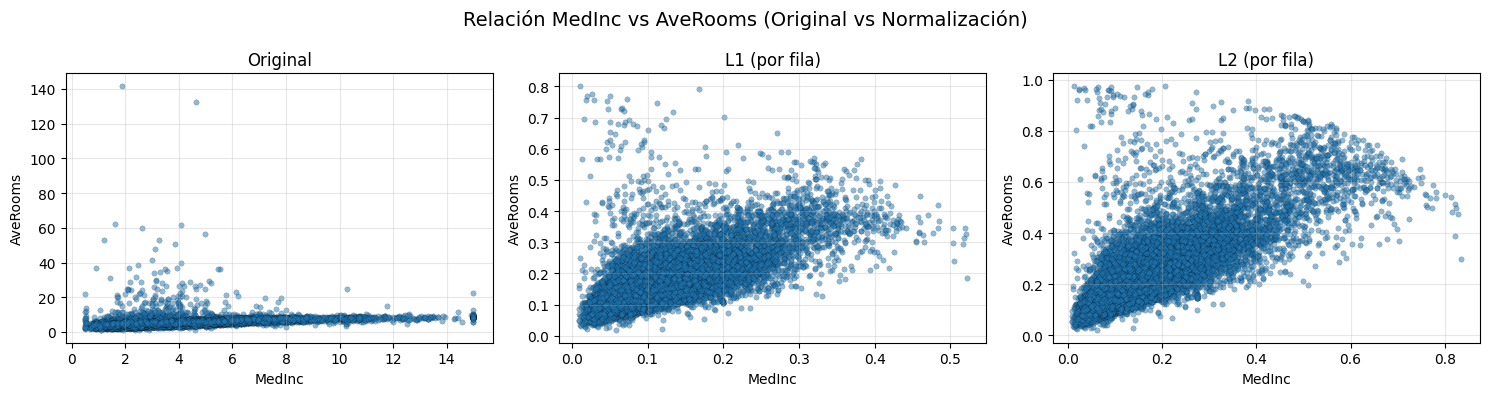

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Relación MedInc vs AveRooms (Original vs Normalización)', fontsize=14)

# Original
axs[0].scatter(
    X['MedInc'],
    X['AveRooms'],
    alpha=0.5,
    s=15,
    edgecolors='black',
    linewidth=0.2
)

axs[0].set_title('Original')
axs[0].set_xlabel('MedInc')
axs[0].set_ylabel('AveRooms')
axs[0].grid(True, alpha=0.3)


# L1
axs[1].scatter(
    df_l1['MedInc'],
    df_l1['AveRooms'],
    alpha=0.5,
    s=15,
    edgecolors='black',
    linewidth=0.2
)

axs[1].set_title('L1 (por fila)')
axs[1].set_xlabel('MedInc')
axs[1].set_ylabel('AveRooms')
axs[1].grid(True, alpha=0.3)


# L2
axs[2].scatter(
    df_l2['MedInc'],
    df_l2['AveRooms'],
    alpha=0.5,
    s=15,
    edgecolors='black',
    linewidth=0.2
)

axs[2].set_title('L2 (por fila)')
axs[2].set_xlabel('MedInc')
axs[2].set_ylabel('AveRooms')
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis

A diferencia de los métodos de escalamiento, las normalizaciones L1 y L2 **operan por observación y no por variable**, ajustando cada fila para que su norma sea igual a 1. Debido a esto, la transformación modifica la distribución de los datos, como se observa en el histograma de la variable HouseAge. Además, también altera la relación entre variables, evidenciado en los gráficos de dispersión.

## <span style="color:#2F749F;"><strong>Ejercicio 4: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con diabetes**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo: `bmi`, `bp` o `s5`).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Transformación logarítmica** usando `np.log()` o `np.log1p()`
   - **Transformación logarítmica reflejada** (útil cuando existe asimetría negativa)
   - **Transformación cuadrática** usando `x²`
   - **Transformación Box-Cox** usando `scipy.stats.boxcox`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación log**
   - Distribución con **log reflejado**
   - Distribución con **transformación cuadrática**
   - Distribución con **transformación Box-Cox**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

## <span style="color:#2F749F;"><strong>Ejercicio 5: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con enfermedades cardíacas**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **Heart Disease** desde la librería `ucimlrepo` usando `load_dataset(\"heart_disease = fetch_ucirepo(id=45)\")`."
2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo:  
   - `chol` (colesterol)  
   - `trestbps` (presión arterial en reposo)  
   - `thalach` (frecuencia cardíaca máxima)).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Raíz cuadrada** usando `np.sqrt()`  
   - **Recíproca** usando `1/x`  
   - **Transformación Yeo-Johnson** usando `PowerTransformer(method="yeo-johnson")`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación raíz cuadrada**
   - Distribución con **transformación recíproca**
   - Distribución con **transformación Yeo-Johnson**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.